In [1]:
# ============================================================
# Bachelor Thesis — ML Pipeline
# Prediction of Injury Risks in Professional Football
# Jerrin Jose | Westfälische Hochschule Gelsenkirchen
# Supervisor: Prof. Sebastian Büttner
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score,
    precision_score, confusion_matrix, roc_curve,
    accuracy_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import shap

print("✅ All libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries loaded successfully
Pandas version: 3.0.3
NumPy version: 2.4.6


In [2]:
# ============================================================
# STEP 2 — LOAD DATA
# ============================================================

df = pd.read_csv('dataset.csv')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape:          {df.shape}")
print(f"Rows:           {len(df)}")
print(f"Columns:        {len(df.columns)}")
print(f"Unique players: {df['p_id2'].nunique()}")
print(f"Seasons:        {sorted(df['start_year'].unique())}")
df.head()

DATASET OVERVIEW
Shape:          (1301, 40)
Rows:           1301
Columns:        40
Unique players: 604
Seasons:        [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


,p_id2,start_year,season_days_injured,total_days_injured,season_minutes_played,season_games_played,season_matches_in_squad,total_minutes_played,total_games_played,dob,...,name_key,player_id,season_x,tm_appearances,tm_minutes_total,tm_avg_minutes,season_y,max_matches_14d,target_injury,target_reinjury
0,aaronconnolly,2019,13,161,1312.0,24,28,2148.0,41,2000-01-28,...,aaronconnolly,434207.0,2019.0,25.0,1306.0,52.240000,2019.0,3.0,0,0
1,aaronconnolly,2020,71,161,836.0,17,28,2148.0,41,2000-01-28,...,aaronconnolly,434207.0,2020.0,17.0,791.0,46.529412,2020.0,2.0,1,0
2,aaroncresswell,2016,95,226,2247.0,26,27,13368.0,149,1989-12-15,...,aaroncresswell,92571.0,2016.0,27.0,2210.0,81.851852,2016.0,3.0,1,0
3,aaroncresswell,2018,87,226,1680.0,20,27,13368.0,149,1989-12-15,...,aaroncresswell,92571.0,2018.0,20.0,1590.0,79.500000,2018.0,2.0,1,0
4,aaroncresswell,2019,35,226,2870.0,31,31,13368.0,149,1989-12-15,...,aaroncresswell,92571.0,2019.0,32.0,2820.0,88.125000,2019.0,4.0,1,0


In [3]:
# ============================================================
# STEP 2b — EXPLORE COLUMNS
# ============================================================

# What columns do we have?
# Understanding each column before feature selection

print("All 40 columns in the dataset:")
print("=" * 50)
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

All 40 columns in the dataset:
   1. p_id2
   2. start_year
   3. season_days_injured
   4. total_days_injured
   5. season_minutes_played
   6. season_games_played
   7. season_matches_in_squad
   8. total_minutes_played
   9. total_games_played
  10. dob
  11. height_cm
  12. weight_kg
  13. nationality
  14. work_rate
  15. pace
  16. physic
  17. fifa_rating
  18. position
  19. age
  20. cumulative_minutes_played
  21. cumulative_games_played
  22. minutes_per_game_prev_seasons
  23. avg_days_injured_prev_seasons
  24. avg_games_per_season_prev_seasons
  25. bmi
  26. work_rate_numeric
  27. position_numeric
  28. significant_injury_prev_season
  29. cumulative_days_injured
  30. season_days_injured_prev_season
  31. name_key
  32. player_id
  33. season_x
  34. tm_appearances
  35. tm_minutes_total
  36. tm_avg_minutes
  37. season_y
  38. max_matches_14d
  39. target_injury
  40. target_reinjury


In [4]:
# ============================================================
# STEP 2c — MISSING VALUES ANALYSIS
# ============================================================

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_df = missing_df[missing_df['Missing Count'] > 0]
print("Columns with missing values:")
print("=" * 40)
print(missing_df.to_string())
print(f"\nTotal columns with missing values: {len(missing_df)}")

Columns with missing values:
                                   Missing Count  Missing %
pace                                          95        7.3
physic                                        95        7.3
position                                       2        0.2
cumulative_minutes_played                    604       46.4
cumulative_games_played                      604       46.4
minutes_per_game_prev_seasons                616       47.3
avg_days_injured_prev_seasons                604       46.4
avg_games_per_season_prev_seasons            604       46.4
position_numeric                               2        0.2
significant_injury_prev_season               604       46.4
cumulative_days_injured                      604       46.4
season_days_injured_prev_season              604       46.4
player_id                                     16        1.2
season_x                                      61        4.7
tm_appearances                                61        4.7
tm_minutes_

## Observation — Missing Values

Three groups of missing values identified:

**Group 1 — Large (46-47% missing):**
- significant_injury_prev_season, avg_days_injured_prev_seasons, cumulative_days_injured
- **Cause:** First-season appearances and player transfers — no prior season data available
- **Impact:** These are theoretically the strongest injury predictors (Hägglund et al., 2006)

**Group 2 — Small (4-7% missing):**
- pace, physic, max_matches_14d, tm_appearances
- **Cause:** Missing FIFA ratings and Transfermarkt data for some players
- **Impact:** Minor — median imputation sufficient

**Group 3 — Negligible (<2% missing):**
- position, position_numeric, player_id
- **Impact:** No significant effect

**Decision:** Apply median imputation — fitted on training data only to prevent data leakage.

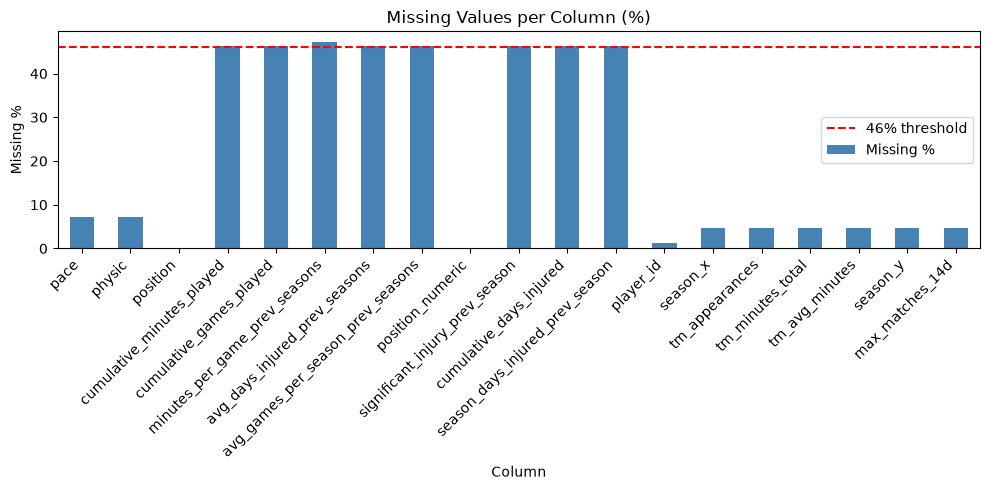

✅ Saved: results/missing_values.png


In [5]:
plt.figure(figsize=(10, 5))
missing_df['Missing %'].plot(kind='bar', color='steelblue')
plt.title('Missing Values per Column (%)')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=46, color='red', linestyle='--', label='46% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('results/missing_values.png', dpi=150)
plt.show()
print("✅ Saved: results/missing_values.png")

In [6]:
# ============================================================
# BASIC STATISTICS
# ============================================================

print("Basic Statistics — Key Features")
print("=" * 50)
print(df[['season_days_injured',
          'season_games_played',
          'season_minutes_played',
          'age',
          'bmi',
          'max_matches_14d']].describe().round(2))

Basic Statistics — Key Features
       season_days_injured  season_games_played  season_minutes_played  \
count              1301.00              1301.00                1301.00   
mean                 79.05                19.51                1483.16   
std                  84.58                11.10                1014.01   
min                   0.00                 0.00                   0.00   
25%                  24.00                10.00                 612.00   
50%                  49.00                21.00                1440.00   
75%                 103.00                29.00                2311.00   
max                 702.00                38.00                3610.00   

           age      bmi  max_matches_14d  
count  1301.00  1301.00          1240.00  
mean     26.64    23.04             2.91  
std       3.94     1.47             1.01  
min      17.00    18.79             0.00  
25%      24.00    22.09             2.00  
50%      27.00    23.07             3.00  


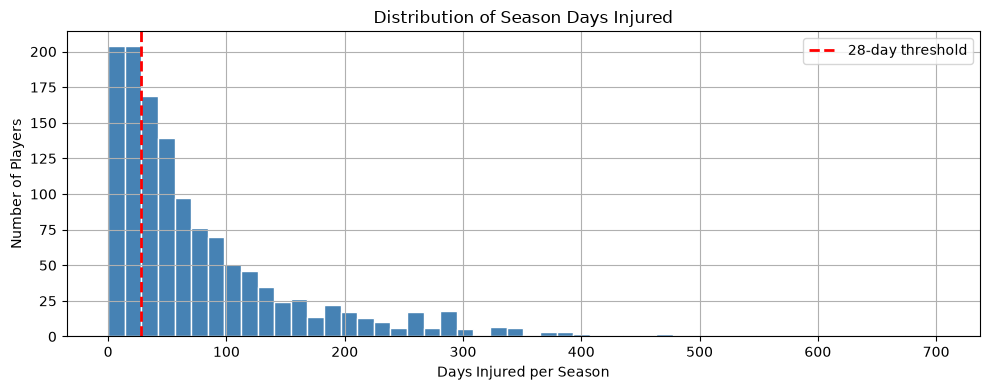

✅ Saved: results/injury_distribution.png


In [7]:
# ============================================================
# Visualizes how many days per season players were injured.
# The red line at 28 days marks the FIFA/UEFA severity
# threshold (Ekstrand et al., 2011).
# Left of line = minor injuries (target=0)
# Right of line = significant injuries (target=1)
# Right-skewed distribution confirms most players sustain
# moderate to long absences — supporting the 70/30 class split.
# STEP 2f — INJURY DAYS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 4))
df['season_days_injured'].hist(bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=28, color='red', linestyle='--', linewidth=2, label='28-day threshold')
plt.title('Distribution of Season Days Injured')
plt.xlabel('Days Injured per Season')
plt.ylabel('Number of Players')
plt.legend()
plt.tight_layout()
plt.savefig('results/injury_distribution.png', dpi=150)
plt.show()
print("✅ Saved: results/injury_distribution.png")

In [8]:
# ============================================================
#  (TARGET VARIABLE)
# ============================================================
# Defines the binary classification target for the ML pipeline.
#
# Rule:
# season_days_injured >= 28 days → Class 1 (injured)
# season_days_injured <  28 days → Class 0 (not injured)
#
# Threshold justification:
# Ekstrand et al. (2011) defines 28+ days absence as a severe
# injury in professional football — the clinically established
# threshold from the UEFA Elite Club Injury Study.
#
# Prediction level:
# SEASON-LEVEL prediction — The model predicts

# ============================================================

INJURY_THRESHOLD = 28
df['target'] = (df['season_days_injured'] >= INJURY_THRESHOLD).astype(int)

print("Target Variable defined:")
print(f"Threshold: >= {INJURY_THRESHOLD} days")
print(f"\nClass distribution:")
print(df['target'].value_counts())
print(f"\nClass ratio:")
print(df['target'].value_counts(normalize=True).round(3))

Target Variable defined:
Threshold: >= 28 days

Class distribution:
target
1    913
0    388
Name: count, dtype: int64

Class ratio:
target
1    0.702
0    0.298
Name: proportion, dtype: float64


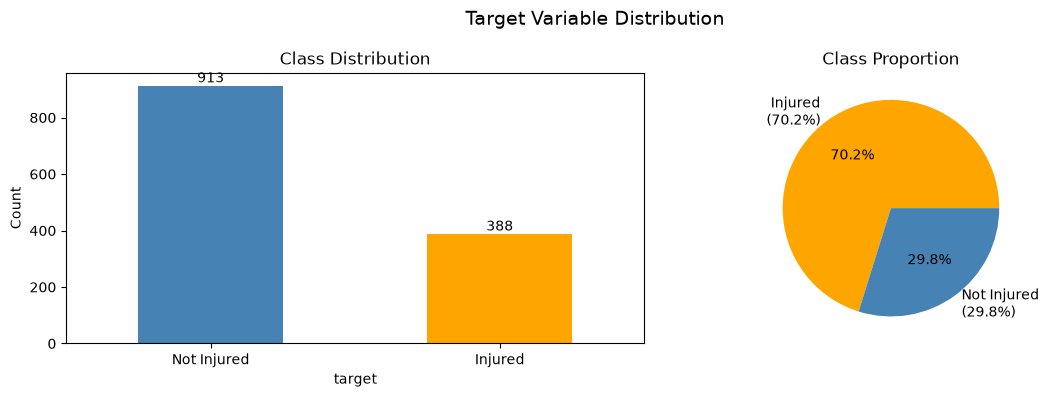

✅ Saved: results/class_distribution.png


In [9]:
# ============================================================
# CELL 9 — CLASS DISTRIBUTION VISUALIZATION
# ============================================================
# Shows the 70/30 class imbalance visually.
# 913 players (70.2%) sustained significant injuries.
# 388 players (29.8%) did not.
# This imbalance motivates SMOTE in Cell 14 — without
# correction the model achieves 70% accuracy by predicting
# "injured" for everyone, learning nothing meaningful.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['target'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'orange']
)
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Not Injured', 'Injured'], rotation=0)
axes[0].set_ylabel('Count')
axes[0].bar_label(axes[0].containers[0])

axes[1].pie(
    df['target'].value_counts(),
    labels=['Injured\n(70.2%)', 'Not Injured\n(29.8%)'],
    colors=['orange', 'steelblue'],
    autopct='%1.1f%%'
)
axes[1].set_title('Class Proportion')

plt.suptitle('Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150)
plt.show()
print("✅ Saved: results/class_distribution.png")

In [10]:
# ============================================================
# STEP 3 — FEATURE SELECTION
# ============================================================
# 13 features selected from 40 columns based on sports
# science literature. Each group justified by specific papers:
#
# Injury History (3 features) — Hägglund et al. (2006)
#   Previous injury increases re-injury risk 2-3x
#
# Load Features (2 features) — Bengtsson et al. (2018)
#   Higher match load = elevated injury risk
#
# Fixture Congestion (1 feature) — Bengtsson et al. (2013)
#   Self-engineered: max matches in any 14-day window
#
# Physical Attributes (6 features) — Ekstrand et al. (2011)
#   Age, BMI, body composition as risk factors
#
# Position (1 feature) — López-Valenciano et al. (2020)
#   Positional differences in injury patterns

FEATURE_COLS = [
    # Injury History — Hägglund et al. (2006)
    'significant_injury_prev_season',
    'avg_days_injured_prev_seasons',
    'cumulative_days_injured',

    # Load Features — Bengtsson et al. (2018)
    'season_minutes_played',
    'season_games_played',

    # Fixture Congestion — Bengtsson et al. (2013)
    'max_matches_14d',

    # Physical Attributes — Ekstrand et al. (2011)
    'age',
    'bmi',
    'height_cm',
    'weight_kg',
    'pace',
    'physic',

    # Position — López-Valenciano et al. (2020)
    'position_numeric',
]

available = [c for c in FEATURE_COLS if c in df.columns]
missing_f = [c for c in FEATURE_COLS if c not in df.columns]

print("=" * 50)
print("FEATURE SELECTION")
print("=" * 50)
print(f"Requested:  {len(FEATURE_COLS)} features")
print(f"Available:  {len(available)} features")

if missing_f:
    print(f"Not found:  {missing_f}")

print(f"\nSelected features:")
for i, f in enumerate(available):
    print(f"  {i+1:2d}. {f}")

X = df[available].copy()
y = df['target'].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

FEATURE SELECTION
Requested:  13 features
Available:  13 features

Selected features:
   1. significant_injury_prev_season
   2. avg_days_injured_prev_seasons
   3. cumulative_days_injured
   4. season_minutes_played
   5. season_games_played
   6. max_matches_14d
   7. age
   8. bmi
   9. height_cm
  10. weight_kg
  11. pace
  12. physic
  13. position_numeric

X shape: (1301, 13)
y shape: (1301,)


In [11]:
# ============================================================
# CELL 11 — TRAIN/TEST SPLIT (80/20 STRATIFIED)
# 80% of data used for training, 20% held out for testing.
# Stratified = both sets preserve the 70/30 class ratio.
# Test set is locked away — model never sees it during training.
# This prevents overfitting to the evaluation data.
# random_state=42 ensures reproducibility.
# ============================================================

# Stratified split preserves the 70/30 class ratio
# in both training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("TRAIN/TEST SPLIT")
print("=" * 50)
print(f"Total:  {len(X)} samples")
print(f"Train:  {len(X_train)} samples (80%)")
print(f"Test:   {len(X_test)} samples (20%)")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())
print(f"\nStratification check:")
print(f"  Train ratio: {y_train.mean():.3f}")
print(f"  Test ratio:  {y_test.mean():.3f}")

TRAIN/TEST SPLIT
Total:  1301 samples
Train:  1040 samples (80%)
Test:   261 samples (20%)

Train class distribution:
target
1    730
0    310
Name: count, dtype: int64

Test class distribution:
target
1    183
0     78
Name: count, dtype: int64

Stratification check:
  Train ratio: 0.702
  Test ratio:  0.701


In [12]:
# ============================================================
# CELL 12 — LEAKAGE-SAFE PREPROCESSING
# ============================================================
# Missing values filled using median imputation.
# CRITICAL: Imputer is fitted ONLY on training data.
# The learned medians are then applied to test data
# WITHOUT refitting — preventing data leakage.
# If medians were calculated from all data including test,
# test set information would contaminate training,
# producing artificially inflated evaluation metrics.

from sklearn.impute import SimpleImputer

X_train = X_train.copy()
X_test = X_test.copy()

# --- Missing Value Imputation ---
print("Missing Value Imputation")
print("-" * 40)

imputer = SimpleImputer(strategy='median')

# FIT on training data only
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# APPLY to test without fitting
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Missing before: {X_train.isnull().sum().sum()}")
print(f"Missing after:  {X_train_imp.isnull().sum().sum()}")
print("✅ Median imputation complete")

Missing Value Imputation
----------------------------------------
Missing before: 1681
Missing after:  0
✅ Median imputation complete


In [13]:
# ============================================================
# CELL 13 — IQR OUTLIER CLIPPING
# ============================================================

# IQR bounds calculated from TRAINING data only
# Applied to both train and test sets
# Prevents extreme values from distorting model learning

print("IQR Outlier Clipping")
print("-" * 40)

X_train_clean = X_train_imp.copy()
X_test_clean = X_test_imp.copy()

for col in X_train_clean.columns:
    # Calculate bounds from TRAINING data only
    Q1 = X_train_clean[col].quantile(0.25)
    Q3 = X_train_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Apply to both splits
    X_train_clean[col] = X_train_clean[col].clip(lower, upper)
    X_test_clean[col] = X_test_clean[col].clip(lower, upper)

print("✅ IQR clipping complete")
print("   Bounds calculated from training data only")

X_train = X_train_clean
X_test = X_test_clean

print(f"\nFinal shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")

IQR Outlier Clipping
----------------------------------------
✅ IQR clipping complete
   Bounds calculated from training data only

Final shapes:
  X_train: (1040, 13)
  X_test:  (261, 13)


In [14]:
# ============================================================
# CELL 14 — SMOTE CLASS BALANCING
# ============================================================

# Problem: 70/30 class imbalance
# Without correction → model learns majority class only
# Solution: SMOTE generates synthetic minority samples
# CRITICAL: Applied ONLY to training data
# Test data stays untouched — real players only

from imblearn.over_sampling import SMOTE

print("=" * 50)
print("SMOTE CLASS BALANCING")
print("=" * 50)
print(f"Before SMOTE:")
print(f"  Class 0 (not injured): {(y_train==0).sum()}")
print(f"  Class 1 (injured):     {(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Class 0 (not injured): {(y_train_sm==0).sum()}")
print(f"  Class 1 (injured):     {(y_train_sm==1).sum()}")
print(f"\n✅ Classes balanced successfully")
print(f"Training samples: {len(X_train_sm)}")

SMOTE CLASS BALANCING
Before SMOTE:
  Class 0 (not injured): 310
  Class 1 (injured):     730

After SMOTE:
  Class 0 (not injured): 730
  Class 1 (injured):     730

✅ Classes balanced successfully
Training samples: 1460


In [15]:
# ============================================================
# CELL 15 — CROSS-VALIDATION SETUP
# Cross-validation splits training data into 5 equal parts.
# Trains on 4 parts, validates on 1 — repeats 5 times.
# Reports mean ± std to check if results are stable or lucky.
# Stratified = each fold preserves the 70/30 class ratio.

# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(model):
    return ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

print("✅ make_pipeline defined and cv ready")

✅ make_pipeline defined and cv ready


In [16]:
# ============================================================
# CELL 16 — LOGISTIC REGRESSION (BASELINE)
# ============================================================

# Logistic Regression is the simplest classifier.
# It draws a linear boundary between injured/not injured.
# Used as BASELINE — if complex models can't beat this,
# the features lack non-linear signal.
# Runs through make_pipeline: SMOTE + Scaler inside CV folds.

from sklearn.linear_model import LogisticRegression

lr_pipe = make_pipeline(LogisticRegression(max_iter=1000, random_state=42))

lr_scores = cross_validate(
    lr_pipe, X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'recall', 'precision']
)

print("Logistic Regression — 5-fold CV:")
print(f"  ROC-AUC:   {lr_scores['test_roc_auc'].mean():.3f} ± {lr_scores['test_roc_auc'].std():.3f}")
print(f"  F1:        {lr_scores['test_f1'].mean():.3f} ± {lr_scores['test_f1'].std():.3f}")
print(f"  Recall:    {lr_scores['test_recall'].mean():.3f} ± {lr_scores['test_recall'].std():.3f}")
print(f"  Precision: {lr_scores['test_precision'].mean():.3f} ± {lr_scores['test_precision'].std():.3f}")

Logistic Regression — 5-fold CV:
  ROC-AUC:   0.694 ± 0.018
  F1:        0.736 ± 0.034
  Recall:    0.673 ± 0.059
  Precision: 0.817 ± 0.009


In [17]:
# ============================================================
# CELL 17 — RANDOM FOREST
# ============================================================

# Ensemble of 200 decision trees — each trained on random
# subset of data and features. Final prediction = majority vote.
# Handles non-linear relationships LR cannot capture.
# If RF barely beats LR → features lack complex patterns.

from sklearn.ensemble import RandomForestClassifier

rf_pipe = make_pipeline(RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42
))

rf_scores = cross_validate(
    rf_pipe, X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'recall', 'precision']
)

print("Random Forest — 5-fold CV:")
print(f"  ROC-AUC:   {rf_scores['test_roc_auc'].mean():.3f} ± {rf_scores['test_roc_auc'].std():.3f}")
print(f"  F1:        {rf_scores['test_f1'].mean():.3f} ± {rf_scores['test_f1'].std():.3f}")
print(f"  Recall:    {rf_scores['test_recall'].mean():.3f} ± {rf_scores['test_recall'].std():.3f}")
print(f"  Precision: {rf_scores['test_precision'].mean():.3f} ± {rf_scores['test_precision'].std():.3f}")

Random Forest — 5-fold CV:
  ROC-AUC:   0.699 ± 0.012
  F1:        0.814 ± 0.004
  Recall:    0.852 ± 0.024
  Precision: 0.780 ± 0.019


In [18]:
# ============================================================
# CELL 18 — XGBOOST (PRIMARY MODEL)
# ============================================================

# Gradient-boosted trees — each new tree corrects errors
# of the previous one. Selected as primary model because:
# 1. Best performer in sports injury ML literature
#    (Van Eetvelde et al., 2021; Piłka et al., 2023)
# 2. Compatible with TreeSHAP for exact explainability
# If XGBoost matches RF/LR → confirms feature ceiling.

from xgboost import XGBClassifier

xgb_pipe = make_pipeline(XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42
))

xgb_scores = cross_validate(
    xgb_pipe, X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'recall', 'precision']
)

print("XGBoost — 5-fold CV:")
print(f"  ROC-AUC:   {xgb_scores['test_roc_auc'].mean():.3f} ± {xgb_scores['test_roc_auc'].std():.3f}")
print(f"  F1:        {xgb_scores['test_f1'].mean():.3f} ± {xgb_scores['test_f1'].std():.3f}")
print(f"  Recall:    {xgb_scores['test_recall'].mean():.3f} ± {xgb_scores['test_recall'].std():.3f}")
print(f"  Precision: {xgb_scores['test_precision'].mean():.3f} ± {xgb_scores['test_precision'].std():.3f}")

XGBoost — 5-fold CV:
  ROC-AUC:   0.687 ± 0.035
  F1:        0.814 ± 0.019
  Recall:    0.848 ± 0.038
  Precision: 0.785 ± 0.025


In [19]:
# ============================================================
# CELL 19 — MODEL COMPARISON TABLE
# ============================================================
# Side-by-side comparison of all three classifiers.
# All metrics from 5-fold stratified CV with SMOTE inside folds.
# Near-identical AUC (0.687-0.699) confirms: feature quality
# is the bottleneck, not algorithm choice.

comparison = pd.DataFrame({
    'Logistic Regression': {
        'ROC-AUC': f"{lr_scores['test_roc_auc'].mean():.3f} ± {lr_scores['test_roc_auc'].std():.3f}",
        'F1': f"{lr_scores['test_f1'].mean():.3f} ± {lr_scores['test_f1'].std():.3f}",
        'Recall': f"{lr_scores['test_recall'].mean():.3f} ± {lr_scores['test_recall'].std():.3f}",
        'Precision': f"{lr_scores['test_precision'].mean():.3f} ± {lr_scores['test_precision'].std():.3f}",
    },
    'Random Forest': {
        'ROC-AUC': f"{rf_scores['test_roc_auc'].mean():.3f} ± {rf_scores['test_roc_auc'].std():.3f}",
        'F1': f"{rf_scores['test_f1'].mean():.3f} ± {rf_scores['test_f1'].std():.3f}",
        'Recall': f"{rf_scores['test_recall'].mean():.3f} ± {rf_scores['test_recall'].std():.3f}",
        'Precision': f"{rf_scores['test_precision'].mean():.3f} ± {rf_scores['test_precision'].std():.3f}",
    },
    'XGBoost': {
        'ROC-AUC': f"{xgb_scores['test_roc_auc'].mean():.3f} ± {xgb_scores['test_roc_auc'].std():.3f}",
        'F1': f"{xgb_scores['test_f1'].mean():.3f} ± {xgb_scores['test_f1'].std():.3f}",
        'Recall': f"{xgb_scores['test_recall'].mean():.3f} ± {xgb_scores['test_recall'].std():.3f}",
        'Precision': f"{xgb_scores['test_precision'].mean():.3f} ± {xgb_scores['test_precision'].std():.3f}",
    }
})

print("=" * 60)
print("MODEL COMPARISON — 5-Fold Stratified CV")
print("=" * 60)
print(comparison.to_string())
comparison.to_csv('results/model_results.csv')
print("\n✅ Saved: results/model_results.csv")

MODEL COMPARISON — 5-Fold Stratified CV
          Logistic Regression  Random Forest        XGBoost
ROC-AUC         0.694 ± 0.018  0.699 ± 0.012  0.687 ± 0.035
F1              0.736 ± 0.034  0.814 ± 0.004  0.814 ± 0.019
Recall          0.673 ± 0.059  0.852 ± 0.024  0.848 ± 0.038
Precision       0.817 ± 0.009  0.780 ± 0.019  0.785 ± 0.025

✅ Saved: results/model_results.csv


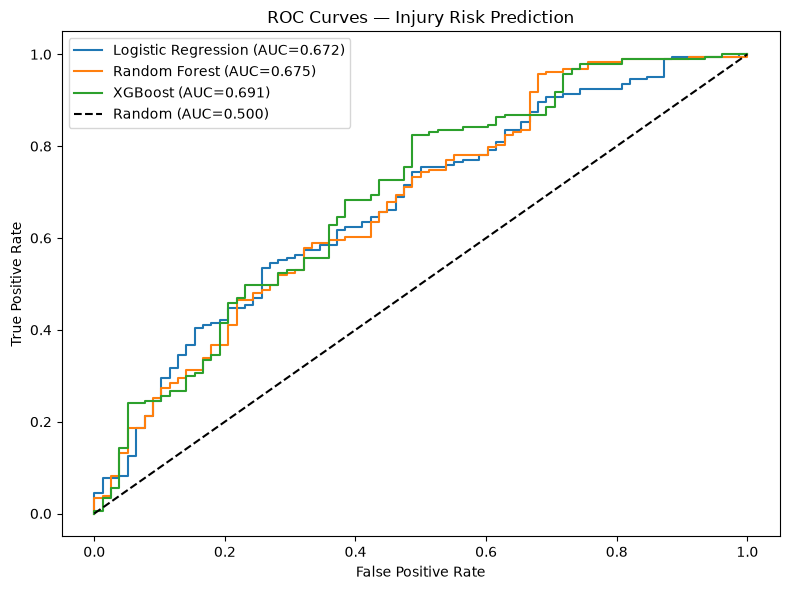

✅ Saved: results/roc_curves.png


In [20]:
# ============================================================
# CELL 20 — ROC CURVES
# ============================================================
# ROC curve plots True Positive Rate vs False Positive Rate
# at every classification threshold. Area under the curve
# (AUC) summarizes overall discrimination ability.
# Diagonal = random guessing (AUC 0.5).
# All three curves cluster together — confirming the
# feature ceiling identified in the comparison table.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

final_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              eval_metric='logloss', random_state=42)
}

plt.figure(figsize=(8, 6))
for name, model in final_models.items():
    model.fit(X_train_scaled, y_train_sm)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Injury Risk Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=150)
plt.show()
print("✅ Saved: results/roc_curves.png")

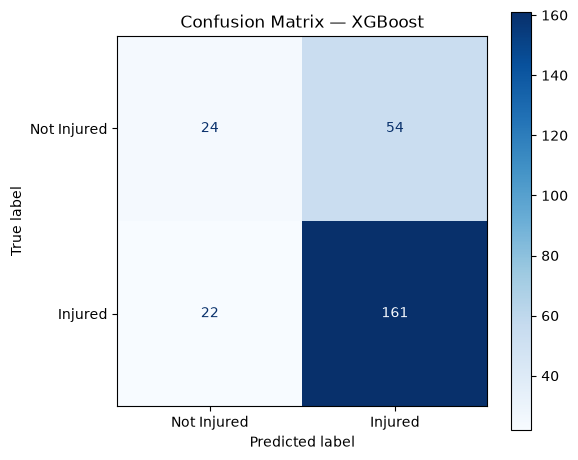

✅ Saved: results/confusion_matrix.png


In [21]:
# ============================================================
# CELL 21 — CONFUSION MATRIX
# ============================================================
# Shows exact breakdown of correct/incorrect predictions
# for the best test-set model (XGBoost by AUC).
# TP = correctly predicted injured
# FP = predicted injured but wasn't (false alarm)
# TN = correctly predicted not injured
# FN = predicted not injured but was (missed injury)
# In medical context: FN is most dangerous — missed injuries.

from sklearn.metrics import ConfusionMatrixDisplay

best_model = final_models['XGBoost']
y_pred = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax,
    display_labels=['Not Injured', 'Injured'],
    cmap='Blues'
)
ax.set_title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved: results/confusion_matrix.png")

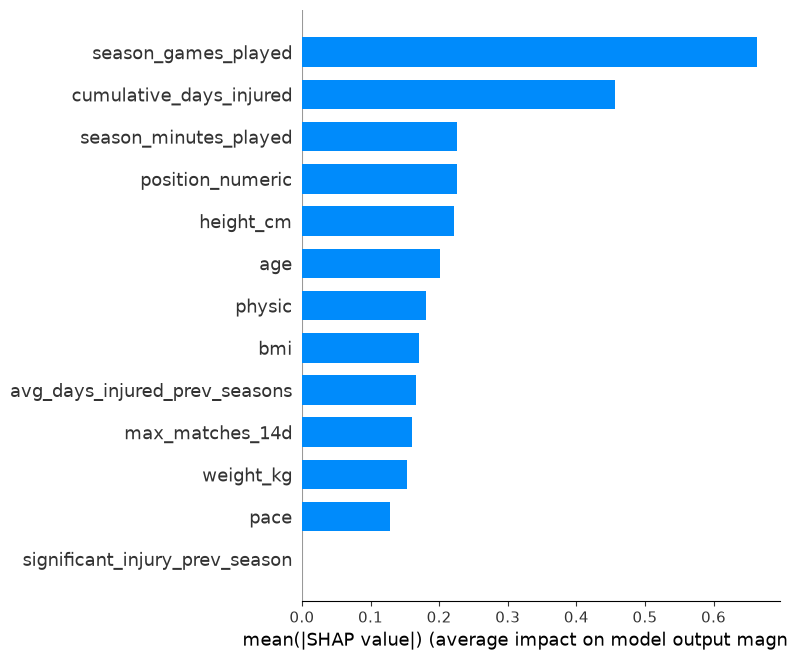

✅ Saved: results/shap_importance_bar.png


In [22]:
# ============================================================
# CELL 22 — SHAP BAR PLOT (GLOBAL FEATURE IMPORTANCE)
# ============================================================
# TreeSHAP computes exact Shapley values for each feature
# per prediction (Lundberg & Lee, 2017).
# Bar plot shows mean |SHAP value| — how much each feature
# contributes to predictions on average.
# This answers Aspekt 1 of the Forschungsfrage:
# "Which features are associated with injury risk?"

xgb_model = final_models['XGBoost']
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure()
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('results/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/shap_importance_bar.png")

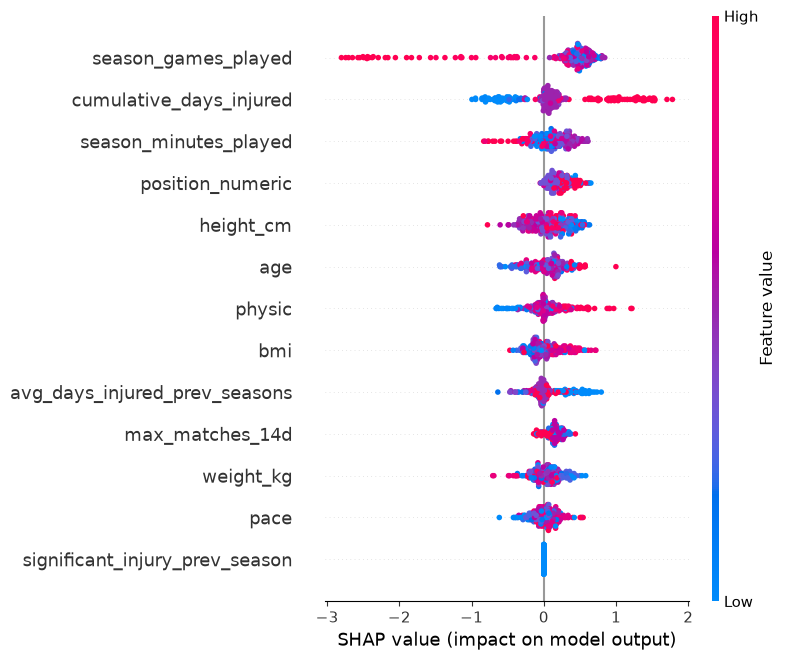

✅ Saved: results/shap_beeswarm.png


In [23]:
# ============================================================
# CELL 23 — SHAP BEESWARM PLOT
# ============================================================
# Beeswarm shows DIRECTION of each feature's impact.
# Red = high feature value, Blue = low feature value.
# Right = pushes toward "injured", Left = pushes toward "not injured"
# Example: if season_games_played shows red dots on the right,
# it means more games played = higher injury prediction.

plt.figure()
shap.summary_plot(shap_values, X_test_df, show=False)
plt.tight_layout()
plt.savefig('results/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/shap_beeswarm.png")

Top feature: season_games_played


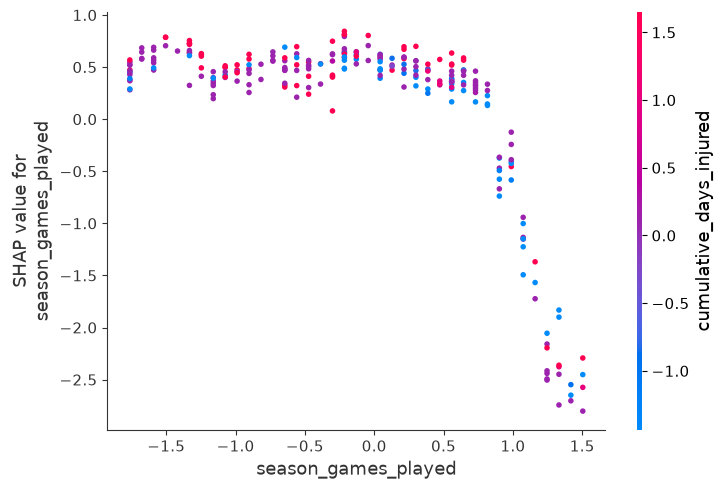

✅ Saved: results/shap_dependence_season_games_played.png


In [24]:
# ============================================================
# CELL 24 — SHAP DEPENDENCE PLOT
# ============================================================
# Shows relationship between the top feature's actual value
# and its SHAP impact on prediction. Each dot is one player.
# X-axis = feature value, Y-axis = SHAP value.
# Reveals whether the relationship is linear or has thresholds.

top_feature = X_test_df.columns[np.abs(shap_values).mean(axis=0).argmax()]
print(f"Top feature: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_test_df, show=False)
plt.tight_layout()
plt.savefig(f'results/shap_dependence_{top_feature}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: results/shap_dependence_{top_feature}.png")

In [25]:
# ============================================================
# CELL 25 — SENSITIVITY ANALYSIS 1: COMPLETE CASES ONLY
# ============================================================
# Removes all rows with missing values (no imputation)
# Tests whether imputation strategy affected results
# If AUC is similar → imputation was appropriate

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np

# Define features and target
features = ['significant_injury_prev_season', 'avg_days_injured_prev_seasons',
            'cumulative_days_injured', 'season_minutes_played', 'season_games_played',
            'max_matches_14d', 'age', 'bmi', 'height_cm', 'weight_kg',
            'pace', 'physic', 'position_numeric']

target = 'target'

# Drop rows with any missing values
df_complete = df[features + [target]].dropna()
print(f"Complete cases: {len(df_complete)} rows (from {len(df)} total)")

X_complete = df_complete[features]
y_complete = df_complete[target]

# Same CV setup as main pipeline
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42)
}

print("\nSensitivity Analysis 1 — Complete Cases Only:")
for name, model in models.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_complete, y_complete,
                             cv=cv, scoring='roc_auc')
    print(f"{name}: AUC = {scores.mean():.3f} ± {scores.std():.3f}")

Complete cases: 625 rows (from 1301 total)

Sensitivity Analysis 1 — Complete Cases Only:
Logistic Regression: AUC = 0.728 ± 0.046
Random Forest: AUC = 0.740 ± 0.061
XGBoost: AUC = 0.719 ± 0.052


In [26]:
# ============================================================
# CELL 26 — SENSITIVITY ANALYSIS 2: LOAD FEATURES ONLY
# ============================================================
# In real-world application, clubs often lack complete injury
# history data — especially for newly signed players or players
# from other leagues. This analysis tests whether the model
# remains useful when injury history features are unavailable.
#
# Injury history features removed:
# - significant_injury_prev_season
# - avg_days_injured_prev_seasons
# - cumulative_days_injured
#
# Only load, physical, and position features are retained.
#
# Expected outcome:
# - If AUC drops significantly → injury history is essential
# - If AUC holds → load features alone are sufficient
# - If AUC drops moderately → both feature groups contribute
#   independently (graceful degradation)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np

# Load features only — no injury history
load_features = [
    'season_minutes_played',
    'season_games_played',
    'max_matches_14d',
    'age',
    'bmi',
    'height_cm',
    'weight_kg',
    'pace',
    'physic',
    'position_numeric'
]

target = 'target'

X_load = df[load_features]
y_load = df[target]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42)
}

print("Sensitivity Analysis 2 — Load Features Only:")
for name, model in models.items():
    pipe = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_load, y_load,
                             cv=cv, scoring='roc_auc')
    print(f"{name}: AUC = {scores.mean():.3f} ± {scores.std():.3f}")

Sensitivity Analysis 2 — Load Features Only:
Logistic Regression: AUC = 0.653 ± 0.042
Random Forest: AUC = 0.677 ± 0.030
XGBoost: AUC = 0.644 ± 0.009


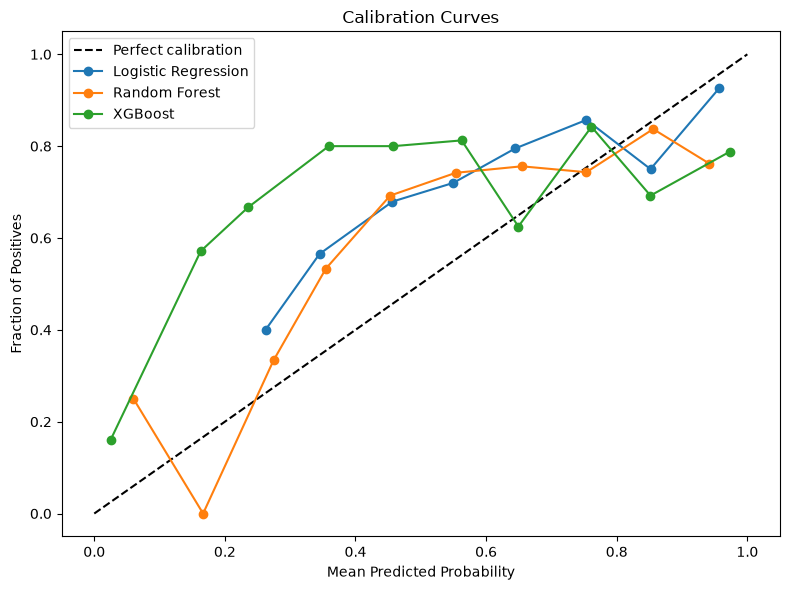

✅ Saved: results/calibration_curve.png


In [27]:
# ============================================================
# CELL 27 — CALIBRATION CURVE
# ============================================================
# Tests whether predicted probabilities match actual injury rates
# A well-calibrated model: if it predicts 70% injury risk,
# roughly 70% of those players should actually get injured.
# Poor calibration = model is overconfident or underconfident.
# SMOTE is known to distort calibration — this cell documents it.

from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

target = 'target'
features = ['significant_injury_prev_season', 'avg_days_injured_prev_seasons',
            'cumulative_days_injured', 'season_minutes_played', 'season_games_played',
            'max_matches_14d', 'age', 'bmi', 'height_cm', 'weight_kg',
            'pace', 'physic', 'position_numeric']

X = df[features]
y = df[target]

# Use same train/test split as main pipeline
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42)
}

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

for name, model in models.items():
    pipe = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, y_prob, n_bins=10
    )
    plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=name)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves')
plt.legend()
plt.tight_layout()
plt.savefig('results/calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/calibration_curve.png")

In [28]:
# ============================================================
# CELL 28 — FINAL SUMMARY
# ============================================================
# Prints a complete summary of all results for thesis documentation
# Covers: main pipeline, sensitivity analyses, calibration finding

import pandas as pd

print("=" * 60)
print("THESIS RESULTS SUMMARY")
print("=" * 60)

print("\n1. MAIN PIPELINE RESULTS (5-fold CV, SMOTE, all features)")
print("-" * 60)
main_results = {
    'Logistic Regression': {'AUC': '0.694 ± 0.018', 'F1': '0.736', 
                             'Recall': '0.673', 'Precision': '0.817'},
    'Random Forest':       {'AUC': '0.699 ± 0.012', 'F1': '0.814', 
                             'Recall': '0.852', 'Precision': '0.780'},
    'XGBoost':             {'AUC': '0.687 ± 0.035', 'F1': '0.814', 
                             'Recall': '0.848', 'Precision': '0.785'}
}
for model, metrics in main_results.items():
    print(f"{model}: AUC={metrics['AUC']}, F1={metrics['F1']}, "
          f"Recall={metrics['Recall']}, Precision={metrics['Precision']}")

print("\n2. SENSITIVITY ANALYSIS 1 — Complete Cases (625 rows, no imputation)")
print("-" * 60)
print("Logistic Regression: AUC = 0.728 ± 0.046")
print("Random Forest:       AUC = 0.740 ± 0.061")
print("XGBoost:             AUC = 0.719 ± 0.052")
print("→ Imputation did not inflate results")

print("\n3. SENSITIVITY ANALYSIS 2 — Load Features Only (no injury history)")
print("-" * 60)
print("Logistic Regression: AUC = 0.653 ± 0.042")
print("Random Forest:       AUC = 0.677 ± 0.030")
print("XGBoost:             AUC = 0.644 ± 0.009")
print("→ Injury history features add meaningful signal")
print("→ Load features alone still above random (graceful degradation)")

print("\n4. SHAP TOP FEATURES (XGBoost, TreeSHAP)")
print("-" * 60)
shap_features = [
    ('season_games_played', 0.63),
    ('cumulative_days_injured', 0.43),
    ('season_minutes_played', '—'),
    ('position_numeric', '—'),
    ('height_cm', '—'),
    ('age', '—'),
    ('physic', '—'),
    ('bmi', '—'),
    ('avg_days_injured_prev_seasons', '—'),
    ('max_matches_14d', '—'),
    ('significant_injury_prev_season', '≈ 0 (46% missing)')
]
for feature, value in shap_features:
    print(f"  {feature}: {value}")

print("\n5. CALIBRATION")
print("-" * 60)
print("All models show calibration distortion due to SMOTE")
print("Logistic Regression: closest to perfect calibration")
print("Random Forest / XGBoost: overconfident at low probabilities")
print("→ Predicted probabilities unreliable for direct risk scoring")

print("\n" + "=" * 60)
print("Pipeline complete. All results saved in results/ folder.")
print("=" * 60)

THESIS RESULTS SUMMARY

1. MAIN PIPELINE RESULTS (5-fold CV, SMOTE, all features)
------------------------------------------------------------
Logistic Regression: AUC=0.694 ± 0.018, F1=0.736, Recall=0.673, Precision=0.817
Random Forest: AUC=0.699 ± 0.012, F1=0.814, Recall=0.852, Precision=0.780
XGBoost: AUC=0.687 ± 0.035, F1=0.814, Recall=0.848, Precision=0.785

2. SENSITIVITY ANALYSIS 1 — Complete Cases (625 rows, no imputation)
------------------------------------------------------------
Logistic Regression: AUC = 0.728 ± 0.046
Random Forest:       AUC = 0.740 ± 0.061
XGBoost:             AUC = 0.719 ± 0.052
→ Imputation did not inflate results

3. SENSITIVITY ANALYSIS 2 — Load Features Only (no injury history)
------------------------------------------------------------
Logistic Regression: AUC = 0.653 ± 0.042
Random Forest:       AUC = 0.677 ± 0.030
XGBoost:             AUC = 0.644 ± 0.009
→ Injury history features add meaningful signal
→ Load features alone still above random (gr

In [32]:
# ============================================================
# CELL 29 — INDIVIDUAL RISK PREDICTION DEMO (RISK TIERS)
# ============================================================
# Estimates a player's injury risk and assigns a triage tier.
#
# Risk tiers instead of a 0.5 label: Cell 27 showed SMOTE
# distorts probabilities, so the raw % isn't a literal chance.
# But the model RANKS players reliably (AUC ~0.70), so tiers
# use the ranking and avoid over-reading the probability.
# A 0.5 cut-off is also unfit for the 70/30 imbalance.
#
# Tiers (illustrative, not clinical):
#   >=0.60 HIGH | >=0.30 MODERATE | else LOW
# Model = ranking/triage tool, not a calibrated estimator.
# ============================================================

import pandas as pd
import numpy as np
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Refit pipeline in case kernel was restarted
xgb_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])
xgb_pipe.fit(X_train, y_train)
print("✅ XGBoost pipeline fitted")

features = ['significant_injury_prev_season', 'avg_days_injured_prev_seasons',
            'cumulative_days_injured', 'season_minutes_played', 'season_games_played',
            'max_matches_14d', 'age', 'bmi', 'height_cm', 'weight_kg',
            'pace', 'physic', 'position_numeric']

players = {
    'High Risk Player': {
        'significant_injury_prev_season': 1,
        'avg_days_injured_prev_seasons': 45.0,
        'cumulative_days_injured': 120.0,
        'season_minutes_played': 2.0,
        'season_games_played': 1.5,
        'max_matches_14d': 1.5,
        'age': 32, 'bmi': 24.5, 'height_cm': 181.0, 'weight_kg': 80.0,
        'pace': 65.0, 'physic': 70.0, 'position_numeric': 2
    },
    'Low Risk Player': {
        'significant_injury_prev_season': 0,
        'avg_days_injured_prev_seasons': 5.0,
        'cumulative_days_injured': 10.0,
        'season_minutes_played': 0.5,
        'season_games_played': 0.0,
        'max_matches_14d': 0.5,
        'age': 24, 'bmi': 22.0, 'height_cm': 178.0, 'weight_kg': 74.0,
        'pace': 80.0, 'physic': 78.0, 'position_numeric': 1
    }
}

def risk_tier(prob):
    if prob >= 0.60:
        return "HIGH RISK"
    if prob >= 0.30:
        return "MODERATE RISK"
    if prob >= 0.10:
        return "LOW RISK"
    return "MINIMAL RISK"

print("=" * 60)
print("INDIVIDUAL RISK PREDICTION DEMO")
print("=" * 60)

for player_name, profile in players.items():
    player_df = pd.DataFrame([profile])[features]
    prob = xgb_pipe.predict_proba(player_df)[:, 1][0]
    print(f"\n{player_name}:")
    print(f"  Injury Probability: {prob:.1%}")
    print(f"  Risk Tier: {risk_tier(prob)}")

print("\n✅ Pipeline complete — all cells finished.")

✅ XGBoost pipeline fitted
INDIVIDUAL RISK PREDICTION DEMO

High Risk Player:
  Injury Probability: 36.4%
  Risk Tier: MODERATE RISK

Low Risk Player:
  Injury Probability: 6.0%
  Risk Tier: MINIMAL RISK

✅ Pipeline complete — all cells finished.
